In [1]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
from matplotlib import pyplot as plt
from utilities_SWING import *

In [2]:
file = './test_data/SWING2026/lacroix_00080_2026-02-06_00-26-58.h5'
mask='./test_data/SWING2026/mask_pyfai.edf'
proc = SAXSProcessor(file, mask=mask,instrument='SWING')

Raw data shape: (10, 10, 1083, 1035)
No motor positions provided. Update filereaders.py if required
Data shape après readout par filereader: (1083, 1035)
Number of frames: 1, Number of pixels (x, z): (1083, 1035)


**Visualisation image moyenne**

✅ SAXS image saved: ./test_data/SWING2026/saxs_images/S0033_M0019_Img_80.png


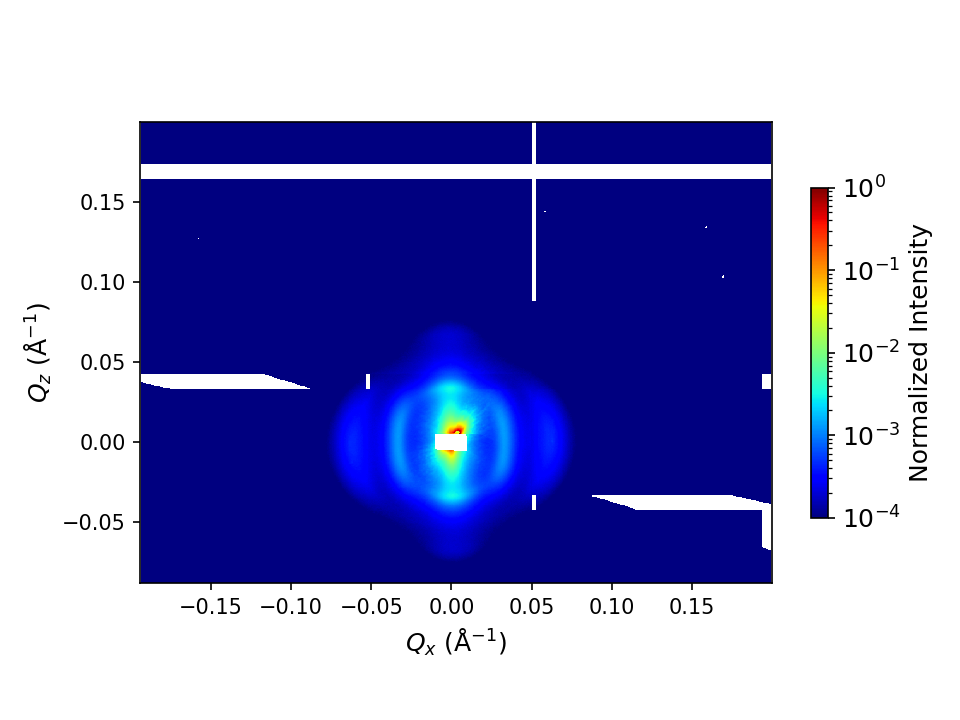

In [13]:
proc.plot2d_vsq()

In [4]:
"""result = view_position_grid_from_single_h5_map(
    h5file=file,
    basler_coords=(186, 309),
    basler_calibration=(370, 370),
    plot=True,
    verbose=False,
    marker_size=5
)"""

'result = view_position_grid_from_single_h5_map(\n    h5file=file,\n    basler_coords=(186, 309),\n    basler_calibration=(370, 370),\n    plot=True,\n    verbose=False,\n    marker_size=5\n)'

Raw data shape: (10, 10, 1083, 1035)
Raw data shape: (10, 10, 1083, 1035)


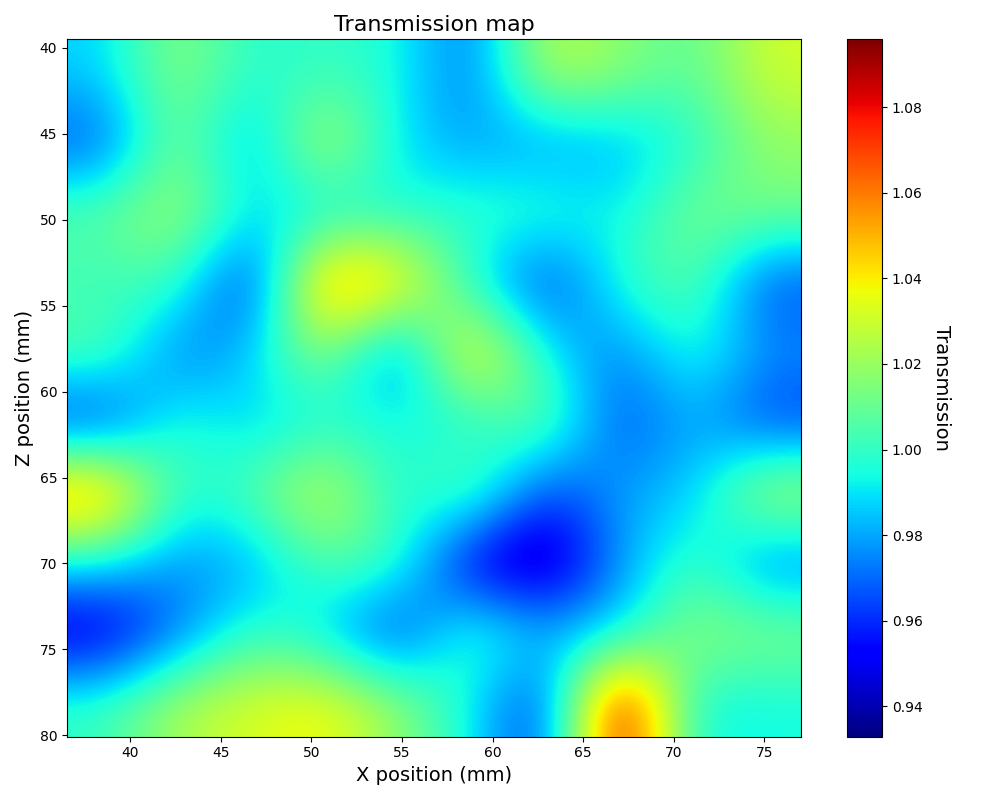

In [ ]:
plot_transmission_map_from_singleh5(file)

**Test profil radial**

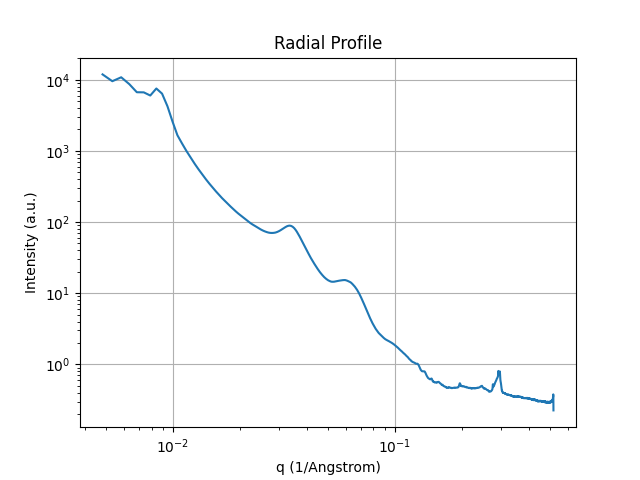

In [6]:
q,I = proc.extract_radial_profile(width=360)

# make loglog plot
plt.figure()
plt.loglog(q, I)
plt.xlabel('q (1/Angstrom)')
plt.ylabel('Intensity (a.u.)')
plt.title('Radial Profile')
plt.grid(True)
plt.show()

**Définition nbre peak et q_range**

In [7]:
nb_peaks=2
qmin = 0.02
qmax=0.1

**Recherche de pics et calcul des distances**

In [ ]:
get_results = detect_peaks_hybrid_interactive(
    proc,
    nb_peaks_init=2,
    qmin_init=0.03,
    qmax_init=0.15,
    fit_window_width_init=1,
    prominence=0.8,
    distance_pts=20)

# Après avoir ajusté les sliders, récupérer les résultats
results_dict = get_results()
distances = results_dict['distances']
distances_std = results_dict['distances_std']
hybrid_results = results_dict['hybrid_results']
peaklist = sorted(results_dict['peaklist'])

Output()

**Nematic Order Parameter**

défintion de la valeur de q (1er pic)

In [9]:
qvalues = peaklist[0]
print("qvalues:", qvalues)

qvalues: 0.03307064842151121


 ## à modifer avec vos valeurs de L,r,radius_pd, et L_pd

In [10]:
# To be completed with actual values (data usually extracted from TEM images)
L = 1000
radius = 100
radius_pd = 0.2
L_pd=1.7  # polydispersity on length is huge!

**calcul paramètre nématique**

/home-local/ratel-ra/anaconda3_c/envs/py311/lib/python3.11/site-packages/pyFAI/azimuthalIntegrator.py:1670: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization



Azimuthal profile completeness check:
  Status: INCOMPLETE
  Found 41 gap(s) with invalid data:
    Gap 1: between χ=-177.7° and χ=-177.0° (1 points)
    Gap 2: between χ=-170.3° and χ=-169.7° (1 points)
    Gap 3: between χ=-167.7° and χ=-167.0° (1 points)
    Gap 4: between χ=-164.3° and χ=-163.7° (1 points)
    Gap 5: between χ=-161.7° and χ=-161.0° (1 points)
    Gap 6: between χ=-116.3° and χ=-115.7° (1 points)
    Gap 7: between χ=-113.0° and χ=-112.3° (1 points)
    Gap 8: between χ=-101.7° and χ=-101.0° (1 points)
    Gap 9: between χ=-98.3° and χ=-97.7° (1 points)
    Gap 10: between χ=-95.0° and χ=-94.4° (1 points)
    Gap 11: between χ=-87.7° and χ=-87.0° (1 points)
    Gap 12: between χ=-84.4° and χ=-83.7° (1 points)
    Gap 13: between χ=-77.7° and χ=-77.0° (1 points)
    Gap 14: between χ=-74.4° and χ=-73.7° (1 points)
    Gap 15: between χ=-71.7° and χ=-71.0° (1 points)
    Gap 16: between χ=-64.4° and χ=-63.7° (1 points)
    Gap 17: between χ=-57.0° and χ=-56.4° (1 poi

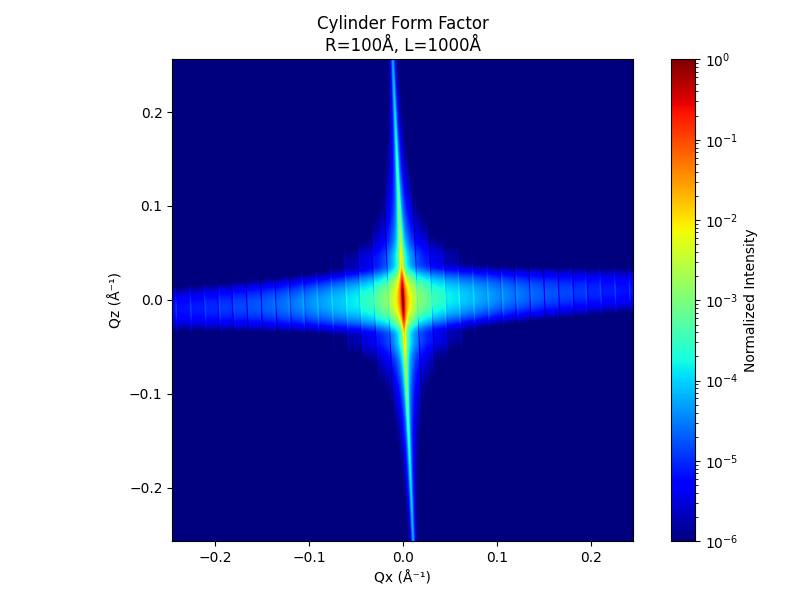


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in ./test_data/SWING2026/azimuthal_profiles/S0033_M0019_B=0_Img80_nematic_determination.png

Fitting results:
x0: 89.62006353981621
S: 0.9573661766279752
R2: 0.9299528875024298


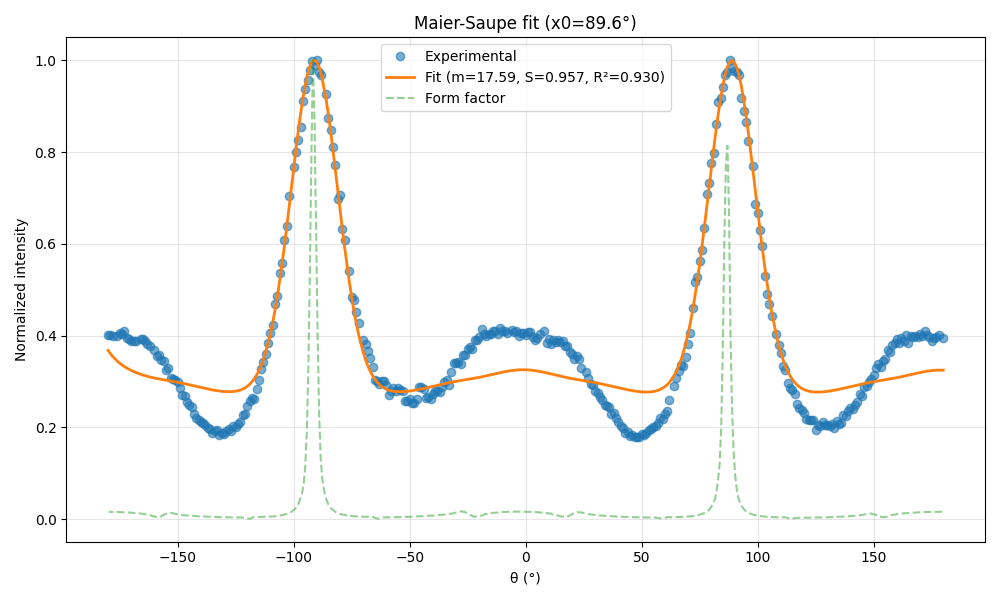

In [11]:
threshold = 0.01
plot = True
apply_mirror = False
verbose = False



S, mean_angle, dict = compute_nematic_parameter(
    processor = proc,
    qvalue = qvalues,
    threshold = threshold,
    radius = radius,
    L = L,
    radius_pd = radius_pd,
    L_pd= L_pd,
    plot = plot,
    verbose = True
        )


**add results to csv**

In [15]:
# save data in dictionary

results={
    'samplename': proc.samplename,
    'B (mT)': proc.B,
    'distance (A)': distances, # array of distances
    'distance_error (A)': distances_std, # array of errors
    'nematic_parameter': S # array of nematic order parameters
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(proc.path,'analysis_results.csv')  # A MODIFIER, je ne sais poas où vous allez stocker ce fichier.
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)
